# Treino da Base usando Sklearn

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

import mlflow
import mlflow.sklearn
import mlflow.xgboost

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from xgboost import XGBClassifier

In [24]:
df = pd.read_csv('../../data/input.csv')
df

,Gender,Tutoring,Extracurricular,Sports,Music,Volunteering,GradeClass,ParentalEducation_label_Ensino Médio,ParentalEducation_label_Faculdade Incompleta,ParentalEducation_label_Nenhum,...,ParentalSupport_label_Muito Alto,ParentalSupport_label_Nenhum,Age_16,Age_17,Age_18,AbscencesGroup_Media,AbscencesGroup_Alta,StudyGroup_Baixa,StudyGroup_Média,StudyGroup_Alta
0,1,1,0,0,1,0,2,0,1,0,...,0,0,0,1,0,0,0,0,0,1
1,0,0,0,0,0,0,1,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0,0,0,0,0,0,4,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,1,0,1,0,0,0,3,0,0,0,...,0,0,0,1,0,1,0,0,1,0
4,1,1,0,0,0,0,4,0,1,0,...,0,0,0,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2387,1,0,1,0,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,1,0
2388,0,1,0,1,0,0,4,1,0,0,...,1,0,0,1,0,0,0,1,0,0
2389,1,0,0,0,0,1,2,0,1,0,...,0,0,1,0,0,1,0,1,0,0
2390,1,0,0,1,1,0,1,0,0,1,...,0,0,1,0,0,1,0,0,1,0


In [25]:
X = df.drop(columns=['GradeClass'])
X

,Gender,Tutoring,Extracurricular,Sports,Music,Volunteering,ParentalEducation_label_Ensino Médio,ParentalEducation_label_Faculdade Incompleta,ParentalEducation_label_Nenhum,ParentalEducation_label_Pós-Graduação,...,ParentalSupport_label_Muito Alto,ParentalSupport_label_Nenhum,Age_16,Age_17,Age_18,AbscencesGroup_Media,AbscencesGroup_Alta,StudyGroup_Baixa,StudyGroup_Média,StudyGroup_Alta
0,1,1,0,0,1,0,0,1,0,0,...,0,0,0,1,0,0,0,0,0,1
1,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,1,0,1,0,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,1,0
4,1,1,0,0,0,0,0,1,0,0,...,0,0,0,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2387,1,0,1,0,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,1,0
2388,0,1,0,1,0,0,1,0,0,0,...,1,0,0,1,0,0,0,1,0,0
2389,1,0,0,0,0,1,0,1,0,0,...,0,0,1,0,0,1,0,1,0,0
2390,1,0,0,1,1,0,0,0,1,0,...,0,0,1,0,0,1,0,0,1,0


In [26]:
y = df['GradeClass']
y

0       2
1       1
2       4
3       3
4       4
       ..
2387    0
2388    4
2389    2
2390    1
2391    1
Name: GradeClass, Length: 2392, dtype: int64

In [27]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

2026/05/19 13:44:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/19 13:44:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'XGBoost_Students_Performance_Model' already exists. Creating a new version of this model...
2026/05/19 13:44:59 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: XGBoost_Students_Performance_Model, version 3
Created version '3' of model 'XGBoost_Students_Performance_Model'.


Accuracy: 0.6179540709812108
{'0': {'precision': 0.2727272727272727, 'recall': 0.14285714285714285, 'f1-score': 0.1875, 'support': 21.0}, '1': {'precision': 0.375, 'recall': 0.3888888888888889, 'f1-score': 0.38181818181818183, 'support': 54.0}, '2': {'precision': 0.40425531914893614, 'recall': 0.48717948717948717, 'f1-score': 0.4418604651162791, 'support': 78.0}, '3': {'precision': 0.36231884057971014, 'recall': 0.30120481927710846, 'f1-score': 0.32894736842105265, 'support': 83.0}, '4': {'precision': 0.8393574297188755, 'recall': 0.8600823045267489, 'f1-score': 0.8495934959349594, 'support': 243.0}, 'accuracy': 0.6179540709812108, 'macro avg': {'precision': 0.4507317724349589, 'recall': 0.4360425285458753, 'f1-score': 0.43794390225809454, 'support': 479.0}, 'weighted avg': {'precision': 0.6086545027363099, 'recall': 0.6179540709812108, 'f1-score': 0.6112205619799459, 'support': 479.0}}


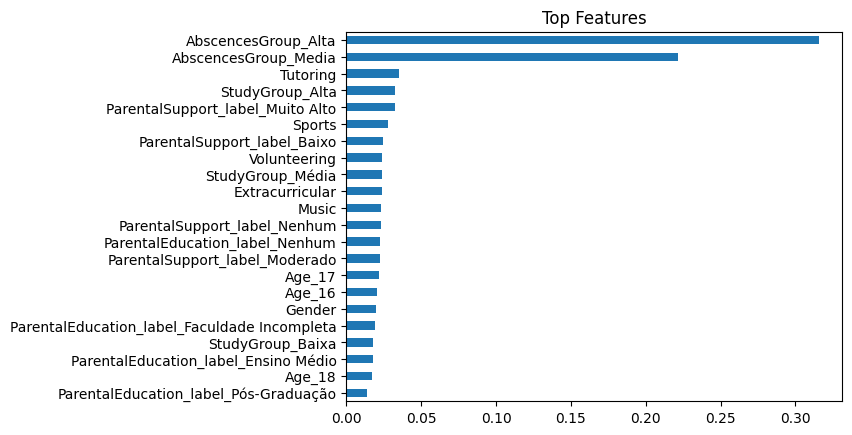

🏃 View run carefree-skunk-602 at: http://127.0.0.1:5000/#/experiments/1/runs/25aa9eb44b6f4fb491c755d4071e4869
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [28]:
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("students_performance_xgboost")

MODEL_NAME = 'XGBoost_Students_Performance_Model'

with mlflow.start_run():

  model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
  )
  model.fit(X_train, y_train)

  mlflow.sklearn.log_model(model, 'model', registered_model_name=MODEL_NAME)

  y_pred = model.predict(X_val)

  # Métricas
  acc = accuracy_score(y_val, y_pred)
  report = classification_report(y_val, y_pred, output_dict=True)

  # Logging de métricas
  mlflow.log_metric("accuracy", acc)

  mlflow.log_metric("precision_0", report['0']['precision'])
  mlflow.log_metric("recall_0", report['0']['recall'])
  mlflow.log_metric("f1_0", report['0']['f1-score'])

  mlflow.log_metric("precision_1", report['1']['precision'])
  mlflow.log_metric("recall_1", report['1']['recall'])
  mlflow.log_metric("f1_1", report['1']['f1-score'])

  mlflow.log_metric("precision_2", report['2']['precision'])
  mlflow.log_metric("recall_2", report['2']['recall'])
  mlflow.log_metric("f1_2", report['2']['f1-score'])

  mlflow.log_metric("precision_3", report['3']['precision'])
  mlflow.log_metric("recall_3", report['3']['recall'])
  mlflow.log_metric("f1_3", report['3']['f1-score'])

  mlflow.log_metric("precision_4", report['4']['precision'])
  mlflow.log_metric("recall_4", report['4']['recall'])
  mlflow.log_metric("f1_4", report['4']['f1-score'])



  # Logging de parâmetros do modelo
  mlflow.log_params({
      "n_estimators": 200,
      "max_depth": 4,
      "learning_rate": 0.05,
      "subsample": 0.8,
      "colsample_bytree": 0.8
  })

  feat_imp = pd.Series(model.feature_importances_, index=X_train.columns)
  feat_imp = feat_imp.sort_values(ascending=False)

  feat_imp.plot(kind='barh')
  plt.gca().invert_yaxis()
  plt.title("Top Features")
  plt.savefig("../../data/feat_imp.png")

  mlflow.log_artifact("../../data/feat_imp.png")

  print("Accuracy:", acc)
  print(report)

  plt.show()


In [29]:
from mlflow.tracking import MlflowClient

client = MlflowClient()

# Pegar última versão do modelo
latest_versions = client.get_latest_versions(MODEL_NAME)

model_version = latest_versions[0].version

# Promover para Production
client.transition_model_version_stage(
    name=MODEL_NAME,
    version=model_version,
    stage="Production"
)

print(f"Modelo versão {model_version} promovido para Production")

/tmp/ipykernel_100253/3657145060.py:6: FutureWarning: ``mlflow.tracking.client.MlflowClient.get_latest_versions`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  latest_versions = client.get_latest_versions(MODEL_NAME)
/tmp/ipykernel_100253/3657145060.py:11: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


Modelo versão 3 promovido para Production


In [30]:
model = mlflow.sklearn.load_model(f"models:/{MODEL_NAME}/Production")